# Discussion 4 Assignment

Alexander Zhang  
alexacz1@uci.edu

## Setup  
Load dependencies and set up environment for discussion 4.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

sns.set_theme(style="whitegrid", palette="muted")

print("Loading Myocardial Infarction dataset (MI.data)...")

df = pd.read_csv("../MI.data", na_values='?', header=None)

target_idx = df.columns[-1] 

X = df.drop(columns=[df.columns[0], target_idx])
y = df[target_idx]

print(f"Dataset successfully loaded!")
print(f"Total Patients: {X.shape[0]}")
print(f"Total Features: {X.shape[1]}")
print(f"Target variable located at index: {target_idx}")

Loading Myocardial Infarction dataset (MI.data)...
Dataset successfully loaded!
Total Patients: 1700
Total Features: 122
Target variable located at index: 123


## Summarization and Visualization

The class imbalance needs to be visualized to see exactly how many patients survived vs. those who passed away from specific complications.


--- DATA SUMMARIZATION ---
Target Class Distribution (Lethal Outcomes):
123
0    84.1
1     6.5
3     3.2
7     1.6
6     1.6
4     1.4
2     1.1
5     0.7
Name: proportion, dtype: float64


/var/folders/k8/p0zmwvf53y155yg14pkmym6w0000gp/T/ipykernel_27784/255065728.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


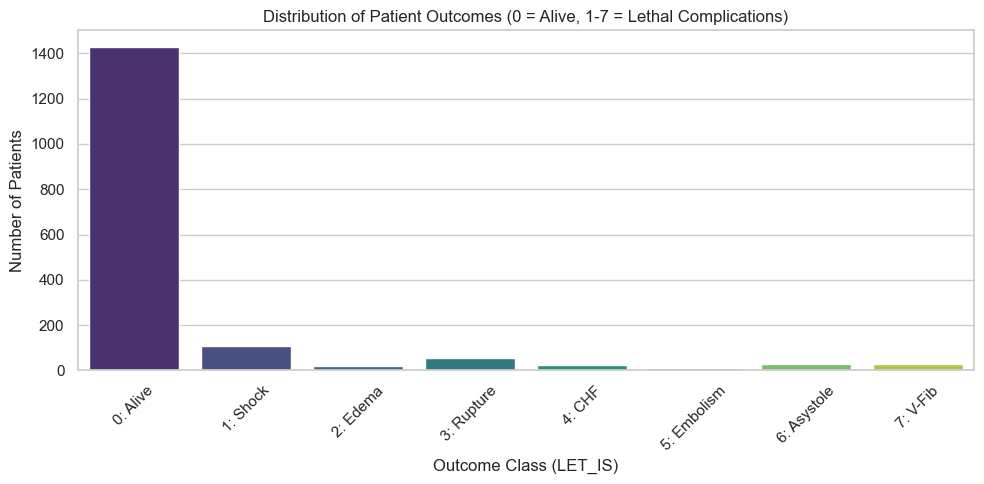


Features with missing data: 110 out of 122


In [5]:
print("\n--- DATA SUMMARIZATION ---")
print("Target Class Distribution (Lethal Outcomes):")
class_dist = y.value_counts(normalize=True).round(3) * 100
print(class_dist)

plt.figure(figsize=(10, 5))
sns.countplot(x=y, palette='viridis')
plt.title("Distribution of Patient Outcomes (0 = Alive, 1-7 = Lethal Complications)")
plt.xlabel("Outcome Class (LET_IS)")
plt.ylabel("Number of Patients")
plt.xticks(ticks=range(8), labels=['0: Alive', '1: Shock', '2: Edema', '3: Rupture', 
                                   '4: CHF', '5: Embolism', '6: Asystole', '7: V-Fib'], rotation=45)
plt.tight_layout()
plt.show()

missing_data = X.isnull().sum()
print(f"\nFeatures with missing data: {(missing_data > 0).sum()} out of {X.shape[1]}")

## Preprocessing and Splitting
Mathematically guess what the empty cells mean, i.e., missing health data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- HANDLING MISSING DATA ---")
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Missing values imputed and features scaled successfully.")


--- HANDLING MISSING DATA ---
Missing values imputed and features scaled successfully.
